## 시계열분석_ARIMA

In [1]:
import numpy as np
import pandas as pd
import statsmodels
from statsmodels.regression import linear_model
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

In [2]:
df = pd.read_csv('air_quality_uci.csv', encoding='cp949')

In [3]:
df['DateTime'] = df['Date'] + ' ' + df['Time']

In [4]:
df['DateTimeIndex'] = pd.to_datetime(df['DateTime'])

In [5]:
df = df.set_index(keys=['DateTimeIndex'])

In [6]:
train_ratio = 0.9
n = len(df)
n_train = int(n*train_ratio)
df_train = df[:n_train]
df_test = df[n_train:]

In [7]:
features = ['T', 'AH']
target = 'PT08_S4'

X_tn = df_train[features]
y_tn = df_train[target]
X_te = df_test[features]
y_te = df_test[target]

In [8]:
X_train = X_tn.asfreq('H')  # 주기를 설정해줘야함
y_train = y_tn.asfreq('H')

C:\Users\User\AppData\Local\Temp\ipykernel_3796\1610638241.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  X_train = X_tn.asfreq('H')  # 주기를 설정해줘야함
C:\Users\User\AppData\Local\Temp\ipykernel_3796\1610638241.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  y_train = y_tn.asfreq('H')


In [9]:
X_test = X_te.asfreq('H')
y_test = y_te.asfreq('H')

C:\Users\User\AppData\Local\Temp\ipykernel_3796\2173709516.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  X_test = X_te.asfreq('H')
C:\Users\User\AppData\Local\Temp\ipykernel_3796\2173709516.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  y_test = y_te.asfreq('H')


In [10]:
y_test

DateTimeIndex
2005-03-26 05:00:00    1309
2005-03-26 06:00:00    1293
2005-03-26 07:00:00    1325
2005-03-26 08:00:00    1458
2005-03-26 09:00:00    1522
                       ... 
2005-03-30 04:00:00    1073
2005-03-30 05:00:00    1109
2005-03-30 06:00:00    1164
2005-03-30 07:00:00    1457
2005-03-30 08:00:00    1533
Freq: h, Name: PT08_S4, Length: 100, dtype: int64

In [11]:
sarimax = ARIMA(endog=y_train, exog=X_train, order=(1,1,0), seasonal_order=(0,1,1,24))
sarimax_fit = sarimax.fit()

In [12]:
sarimax_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            PT08_S4   No. Observations:                  900
Model:             ARIMA(1, 1, 0)x(0, 1, [1], 24)   Log Likelihood               -5244.604
Date:                            Mon, 03 Nov 2025   AIC                          10499.208
Time:                                    14:43:20   BIC                          10523.079
Sample:                                02-16-2005   HQIC                         10508.340
                                     - 03-26-2005                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
T            -16.1453      3.231     -4.996      0.000     -22.479      -9.812
AH            24.5826      3.539      6.946      0.000      17.646      31.520
ar.L1         -0.0230      0.026     -0.885      0.376      -0.074       0.028
ma.S.L24      -0.8801      0.015    -59.336      0.000      -0.909      -0.851
sigma2      9040.4794    302.297     29.906      0.000    8447.988    9632.971
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               225.36
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               1.78   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
# train 데이터로 예측 
sarimax_fit.predict()

DateTimeIndex
2005-02-16 17:00:00    -121.174295
2005-02-16 18:00:00    1022.755962
2005-02-16 19:00:00    1115.900212
2005-02-16 20:00:00    1306.084612
2005-02-16 21:00:00    1552.961913
                          ...     
2005-03-26 00:00:00    1427.921306
2005-03-26 01:00:00    1489.220439
2005-03-26 02:00:00    1425.691600
2005-03-26 03:00:00    1336.854742
2005-03-26 04:00:00    1337.022572
Freq: h, Name: predicted_mean, Length: 900, dtype: float64

In [14]:
sarimax_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            PT08_S4   No. Observations:                  900
Model:             ARIMA(1, 1, 0)x(0, 1, [1], 24)   Log Likelihood               -5244.604
Date:                            Mon, 03 Nov 2025   AIC                          10499.208
Time:                                    14:43:20   BIC                          10523.079
Sample:                                02-16-2005   HQIC                         10508.340
                                     - 03-26-2005                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
T            -16.1453      3.231     -4.996      0.000     -22.479      -9.812
AH            24.5826      3.539      6.946      0.000      17.646      31.520
ar.L1         -0.0230      0.026     -0.885      0.376      -0.074       0.028
ma.S.L24      -0.8801      0.015    -59.336      0.000      -0.909      -0.851
sigma2      9040.4794    302.297     29.906      0.000    8447.988    9632.971
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               225.36
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               1.78   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.48
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [15]:
# train 데이터로 예측
train_predict = sarimax_fit.predict()
train_predict

DateTimeIndex
2005-02-16 17:00:00    -121.174295
2005-02-16 18:00:00    1022.755962
2005-02-16 19:00:00    1115.900212
2005-02-16 20:00:00    1306.084612
2005-02-16 21:00:00    1552.961913
                          ...     
2005-03-26 00:00:00    1427.921306
2005-03-26 01:00:00    1489.220439
2005-03-26 02:00:00    1425.691600
2005-03-26 03:00:00    1336.854742
2005-03-26 04:00:00    1337.022572
Freq: h, Name: predicted_mean, Length: 900, dtype: float64

In [16]:
# test 데이터로 예측
test_predict = sarimax_fit.forecast(steps=len(X_test), exog=X_test)
test_predict

2005-03-26 05:00:00    1317.998473
2005-03-26 06:00:00    1334.624957
2005-03-26 07:00:00    1413.269919
2005-03-26 08:00:00    1767.346876
2005-03-26 09:00:00    1956.451181
                          ...     
2005-03-30 04:00:00    1571.202452
2005-03-30 05:00:00    1576.185183
2005-03-30 06:00:00    1576.608122
2005-03-30 07:00:00    1660.099110
2005-03-30 08:00:00    1998.104530
Freq: h, Name: predicted_mean, Length: 100, dtype: float64

In [17]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test, test_predict)

178777.26546803745

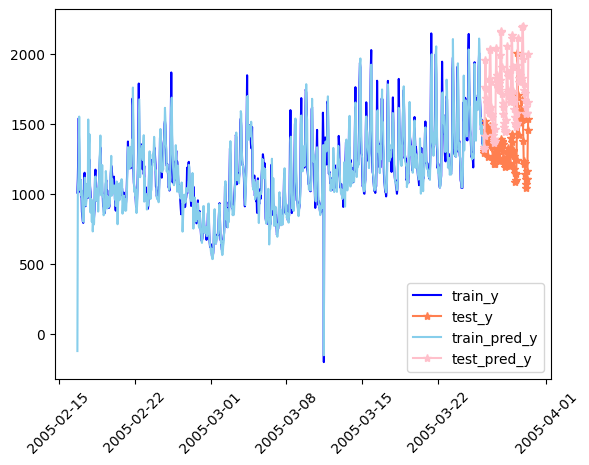

In [18]:
import matplotlib.pyplot as plt
plt.plot(y_tn, color='blue', label='train_y')
plt.plot(y_te, color='coral', label='test_y', marker='*')
plt.plot(train_predict, color='skyblue', label='train_pred_y')
plt.plot(test_predict, color='pink', label='test_pred_y', marker='*')
plt.legend()
plt.xticks(rotation=45)
plt.show()

### ARCH

In [19]:
arch = arch_model(y_train, vol='ARCH', p=1)
arch_fit = arch.fit()

Iteration:      1,   Func. Count:      5,   Neg. LLF: 6145.47259860504
Iteration:      2,   Func. Count:     10,   Neg. LLF: 6141.005719608767
Iteration:      3,   Func. Count:     14,   Neg. LLF: 6129.271584813113
Iteration:      4,   Func. Count:     18,   Neg. LLF: 6120.173201081256
Iteration:      5,   Func. Count:     22,   Neg. LLF: 6119.6107533912
Iteration:      6,   Func. Count:     26,   Neg. LLF: 6119.58801481248
Iteration:      7,   Func. Count:     30,   Neg. LLF: 6119.587805998994
Iteration:      8,   Func. Count:     34,   Neg. LLF: 6119.58780205838
Iteration:      9,   Func. Count:     38,   Neg. LLF: 6119.587795657499
Iteration:     10,   Func. Count:     42,   Neg. LLF: 6119.587779801619
Iteration:     11,   Func. Count:     46,   Neg. LLF: 6119.587708846945
Iteration:     12,   Func. Count:     50,   Neg. LLF: 6119.587607974648
Iteration:     13,   Func. Count:     54,   Neg. LLF: 6119.587205533602
Iteration:     14,   Func. Count:     58,   Neg. LLF: 6119.5866560883

C:\Users\User\miniconda3\envs\py3_11_9\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.674e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [20]:
arch_fit.forecast

<bound method ARCHModelFixedResult.forecast of                       Constant Mean - ARCH Model Results                      
Dep. Variable:                PT08_S4   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -6114.03
Distribution:                  Normal   AIC:                           12234.1
Method:            Maximum Likelihood   BIC:                           12248.5
                                        No. Observations:                  900
Date:                Mon, Nov 03 2025   Df Residuals:                      899
Time:                        14:43:20   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         

In [21]:
pred_var = arch_fit.forecast(horizon=len(y_test))

In [22]:
pred_var.variance.values

array([[  91080.37451842,  101104.00448292,  111127.63444743,
         121151.26441194,  131174.89437644,  141198.52434095,
         151222.15430546,  161245.78426997,  171269.41423447,
         181293.04419898,  191316.67416349,  201340.30412799,
         211363.9340925 ,  221387.56405701,  231411.19402151,
         241434.82398602,  251458.45395053,  261482.08391503,
         271505.71387954,  281529.34384405,  291552.97380855,
         301576.60377306,  311600.23373757,  321623.86370207,
         331647.49366658,  341671.12363109,  351694.75359559,
         361718.3835601 ,  371742.01352461,  381765.64348911,
         391789.27345362,  401812.90341813,  411836.53338263,
         421860.16334714,  431883.79331165,  441907.42327615,
         451931.05324066,  461954.68320517,  471978.31316968,
         482001.94313418,  492025.57309869,  502049.2030632 ,
         512072.8330277 ,  522096.46299221,  532120.09295672,
         542143.72292122,  552167.35288573,  562190.98285024,
        

In [23]:
pred_arch = np.sqrt(pred_var.variance.values[0])
pred_arch

array([ 301.79525264,  317.96855895,  333.35811742,  348.06790201,
        362.18074821,  375.76392102,  388.87292822,  401.55421087,
        413.8470904 ,  425.785209  ,  437.39761564,  448.70959888,
        459.74333502,  470.51839928,  481.05217391,  491.36017745,
        501.45633304,  511.35318901,  521.06210175,  530.59338843,
        539.95645547,  549.15990729,  558.21163884,  567.11891496,
        575.88843856,  584.5264097 ,  593.03857682,  601.43028155,
        609.70649785,  617.87186656,  625.93072576,  633.88713776,
        641.74491302,  649.50763148,  657.17866164,  664.76117762,
        672.25817454,  679.67248231,  687.00677811,  694.26359773,
        701.44534577,  708.55430495,  715.59264462,  722.56242844,
        729.4656215 ,  736.30409677,  743.07964101,  749.79396027,
        756.44868485,  763.045374  ,  769.5855201 ,  776.07055266,
        782.50184196,  788.88070241,  795.20839571,  801.48613373,
        807.71508128,  813.89635857,  820.0310436 ,  826.12017

### GARCH

In [25]:
garch = arch_model(y_train, vol='GARCH', p=15, q=15)
garch_fit = garch.fit()

C:\Users\User\miniconda3\envs\py3_11_9\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.674e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


Iteration:      1,   Func. Count:     34,   Neg. LLF: 6179.791526058767
Iteration:      2,   Func. Count:     67,   Neg. LLF: 6123.400134454773
Iteration:      3,   Func. Count:    101,   Neg. LLF: 6749.014166346347
Iteration:      4,   Func. Count:    137,   Neg. LLF: 7869.965520546248
Iteration:      5,   Func. Count:    172,   Neg. LLF: 6110.225012652049
Iteration:      6,   Func. Count:    206,   Neg. LLF: 6103.989699723374
Iteration:      7,   Func. Count:    239,   Neg. LLF: 6102.170451711247
Iteration:      8,   Func. Count:    272,   Neg. LLF: 6115.979447936562
Iteration:      9,   Func. Count:    306,   Neg. LLF: 6097.008635869665
Iteration:     10,   Func. Count:    339,   Neg. LLF: 6086.228705860157
Iteration:     11,   Func. Count:    372,   Neg. LLF: 6080.353345273148
Iteration:     12,   Func. Count:    405,   Neg. LLF: 6079.990156544641
Iteration:     13,   Func. Count:    439,   Neg. LLF: 6076.5507066054615
Iteration:     14,   Func. Count:    472,   Neg. LLF: 6076.6985

In [26]:
pred_var = garch_fit.forecast(horizon=len(y_test))

In [27]:
pred_garch = np.sqrt(pred_var.variance.values[0])
pred_garch

array([323.35513367, 366.92318479, 430.5431706 , 495.67626007,
       534.67427016, 548.30364666, 553.72253393, 550.06646895,
       551.14569003, 549.34444555, 541.40179543, 533.91817013,
       525.94203286, 520.8585087 , 518.30908928, 519.64116895,
       525.22430542, 533.18486572, 541.46853982, 549.42553901,
       556.40627667, 562.86297376, 568.63521866, 573.34949483,
       577.14754076, 580.08684205, 582.44642785, 584.44845619,
       586.38250303, 588.53942949, 591.06501539, 593.95644369,
       597.1660684 , 600.60343741, 604.21553134, 607.94146424,
       611.69815908, 615.41885347, 619.04614218, 622.547088  ,
       625.90718282, 629.13350854, 632.25294222, 635.30030464,
       638.3073425 , 641.29990683, 644.29545501, 647.30636376,
       650.3397685 , 653.39639112, 656.4721751 , 659.55930453,
       662.64822477, 665.72908526, 668.7932992 , 671.83485473,
       674.85067887, 677.84018812, 680.80467372, 683.74655774,
       686.66894425, 689.57519428, 692.4684504 , 695.35

### SARIMAX + GARCH 실습 

- SARIMAX 학습 

In [29]:
sarimax = ARIMA(endog=y_train, exog=X_train, order=(1,1,0), seasonal_order=(0,1,1,12))
sarimax_fit = sarimax.fit()

In [30]:
# sarimax 모형 에러
sarimax_residual = sarimax_fit.resid
sarimax_residual

DateTimeIndex
2005-02-16 17:00:00    1015.103934
2005-02-16 18:00:00      97.774047
2005-02-16 19:00:00     189.351139
2005-02-16 20:00:00     241.135166
2005-02-16 21:00:00    -249.359670
                          ...     
2005-03-26 00:00:00     111.494734
2005-03-26 01:00:00     -46.802526
2005-03-26 02:00:00    -101.757225
2005-03-26 03:00:00      37.279489
2005-03-26 04:00:00     -22.630145
Freq: h, Length: 900, dtype: float64

- GARCH 학습 

In [31]:
# 잔차 변환
adjusted_constant = 0.1
adj_sarimax_residual = sarimax_residual*adjusted_constant

In [32]:
adj_sarimax_residual.describe()

count    900.000000
mean       0.105443
std       12.104562
min      -53.930939
25%       -5.470847
50%       -0.338875
75%        4.947957
max      101.510393
dtype: float64

In [33]:
garch = arch_model(adj_sarimax_residual, vol='GARCH', p=20, q=20)
garch_fit = garch.fit()

Iteration:      1,   Func. Count:     44,   Neg. LLF: 3474.8258760095614
Iteration:      2,   Func. Count:     88,   Neg. LLF: 3447.6591615241346
Iteration:      3,   Func. Count:    132,   Neg. LLF: 3564.2729707697654
Iteration:      4,   Func. Count:    177,   Neg. LLF: 3674.7458297447956
Iteration:      5,   Func. Count:    222,   Neg. LLF: 3523.855981378849
Iteration:      6,   Func. Count:    266,   Neg. LLF: 3635.714517320952
Iteration:      7,   Func. Count:    310,   Neg. LLF: 3545.886619275498
Iteration:      8,   Func. Count:    354,   Neg. LLF: 3444.7621243574886
Iteration:      9,   Func. Count:    398,   Neg. LLF: 3493.460883928603
Iteration:     10,   Func. Count:    442,   Neg. LLF: 3441.8647265530144
Iteration:     11,   Func. Count:    486,   Neg. LLF: 3452.0562682743284
Iteration:     12,   Func. Count:    530,   Neg. LLF: 3471.124183994674
Iteration:     13,   Func. Count:    574,   Neg. LLF: 5753.110053476506
Iteration:     14,   Func. Count:    618,   Neg. LLF: 504

- SARIMAX로 MU 예측 

In [34]:
pred_mu = sarimax_fit.forecast(steps=len(X_test), exog=X_test)
pred_mu

2005-03-26 05:00:00    1343.640238
2005-03-26 06:00:00    1424.351506
2005-03-26 07:00:00    1527.959918
2005-03-26 08:00:00    1668.701522
2005-03-26 09:00:00    1635.782580
                          ...     
2005-03-30 04:00:00    1373.488594
2005-03-30 05:00:00    1384.861981
2005-03-30 06:00:00    1464.676271
2005-03-30 07:00:00    1568.636224
2005-03-30 08:00:00    1708.312431
Freq: h, Name: predicted_mean, Length: 100, dtype: float64

- GARCH로 residual 예측 

In [35]:
adj_forecast_residual = garch_fit.forecast(horizon=len(y_test))
adj_forecast_residual

In [36]:
adj_forecast_residual.variance.values

array([[ 56.02294419, 161.55408128, 180.64611698, 327.61444113,
        300.32182142, 254.12227567, 173.93583859, 156.30209173,
        107.85259487,  93.26958101,  70.45962962,  71.75266163,
         85.03961812, 146.02519099, 183.14269276, 256.49152043,
        256.80345601, 232.81656175, 186.76199358, 161.21324096,
        127.65892886, 108.88462941,  92.07383548,  91.51376156,
        103.52581463, 141.35790738, 175.14353078, 217.41096244,
        225.74658972, 214.37074067, 187.42947249, 164.75438594,
        139.76889852, 121.96952973, 108.65828386, 106.86684486,
        116.05228176, 140.58635631, 166.83499787, 194.00766513,
        203.79893679, 199.32870689, 183.48419655, 166.01599171,
        147.150533  , 131.95595861, 121.12774178, 118.64806808,
        124.98597614, 141.2468028 , 160.50917092, 179.18951487,
        188.26722666, 187.43063429, 178.19778785, 165.58158727,
        151.45544321, 139.14515286, 130.31385443, 127.5489177 ,
        131.56601774, 142.40808734, 156.

In [37]:
forecast_residual = np.sqrt(adj_forecast_residual.variance.values)/adjusted_constant

In [38]:
forecast_residual

array([[ 74.8484764 , 127.10392649, 134.40465653, 181.00122683,
        173.2979577 , 159.41213118, 131.88473702, 125.02083495,
        103.85210391,  96.57617771,  83.94023446,  84.70694283,
         92.21692801, 120.84088339, 135.33022307, 160.15352648,
        160.25088331, 152.5832762 , 136.66089184, 126.96977631,
        112.98625087, 104.34779797,  95.95511215,  95.66282536,
        101.74763615, 118.89403155, 132.34180397, 147.44862239,
        150.24865714, 146.4140501 , 136.90488395, 128.35668504,
        118.22389713, 110.43981607, 104.23928427, 103.37642132,
        107.7275646 , 118.56911753, 129.16462282, 139.28663437,
        142.75816502, 141.18381879, 135.45633856, 128.8471931 ,
        121.30561941, 114.87208478, 110.05804913, 108.92569398,
        111.79712704, 118.84729816, 126.69221402, 133.8616879 ,
        137.21050494, 136.90530826, 133.49074419, 128.67850919,
        123.06723496, 117.95980369, 114.15509381, 112.93755695,
        114.7022309 , 119.33485968, 124.

In [39]:
pred_residual = pd.Series(forecast_residual[-1,:], index=y_test.index)
pred_residual  # 예측한 분산

DateTimeIndex
2005-03-26 05:00:00     74.848476
2005-03-26 06:00:00    127.103926
2005-03-26 07:00:00    134.404657
2005-03-26 08:00:00    181.001227
2005-03-26 09:00:00    173.297958
                          ...    
2005-03-30 04:00:00    119.371170
2005-03-30 05:00:00    119.541620
2005-03-30 06:00:00    120.805260
2005-03-30 07:00:00    122.748674
2005-03-30 08:00:00    124.795454
Freq: h, Length: 100, dtype: float64

In [40]:
e_t = np.random.randn(len(X_test))
y_hat = pred_mu + pred_residual*e_t  # 추정한 mu와 a_t를 더함 (a_t는 pred_residual*e_t)

In [41]:
y_hat

2005-03-26 05:00:00    1362.781467
2005-03-26 06:00:00    1507.941766
2005-03-26 07:00:00    1397.235326
2005-03-26 08:00:00    1863.573919
2005-03-26 09:00:00    1867.309269
                          ...     
2005-03-30 04:00:00    1215.435111
2005-03-30 05:00:00    1313.725022
2005-03-30 06:00:00    1240.606282
2005-03-30 07:00:00    1792.091771
2005-03-30 08:00:00    1587.177616
Freq: h, Length: 100, dtype: float64

In [42]:
y_test

DateTimeIndex
2005-03-26 05:00:00    1309
2005-03-26 06:00:00    1293
2005-03-26 07:00:00    1325
2005-03-26 08:00:00    1458
2005-03-26 09:00:00    1522
                       ... 
2005-03-30 04:00:00    1073
2005-03-30 05:00:00    1109
2005-03-30 06:00:00    1164
2005-03-30 07:00:00    1457
2005-03-30 08:00:00    1533
Freq: h, Name: PT08_S4, Length: 100, dtype: int64